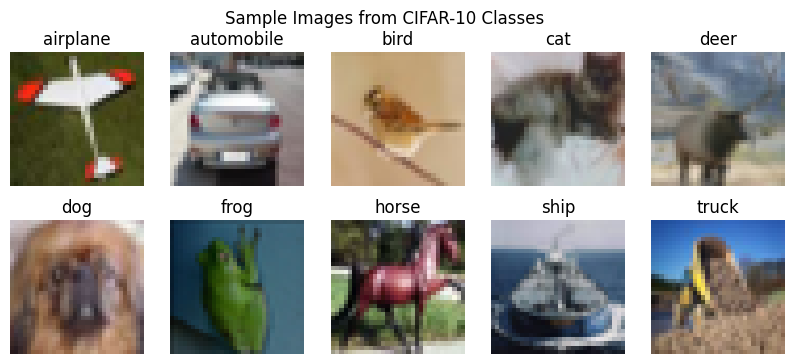

Training with params: {'dropout_rate': 0.3, 'hidden_units': 128, 'learning_rate': 0.001}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with params: {'dropout_rate': 0.3, 'hidden_units': 128, 'learning_rate': 0.0005}
Training with params: {'dropout_rate': 0.3, 'hidden_units': 256, 'learning_rate': 0.001}
Training with params: {'dropout_rate': 0.3, 'hidden_units': 256, 'learning_rate': 0.0005}
Training with params: {'dropout_rate': 0.5, 'hidden_units': 128, 'learning_rate': 0.001}
Training with params: {'dropout_rate': 0.5, 'hidden_units': 128, 'learning_rate': 0.0005}
Training with params: {'dropout_rate': 0.5, 'hidden_units': 256, 'learning_rate': 0.001}
Training with params: {'dropout_rate': 0.5, 'hidden_units': 256, 'learning_rate': 0.0005}

Best Hyperparameters: {'dropout_rate': 0.3, 'hidden_units': 256, 'learning_rate': 0.0005}
Best Validation Accuracy: 0.43353334069252014


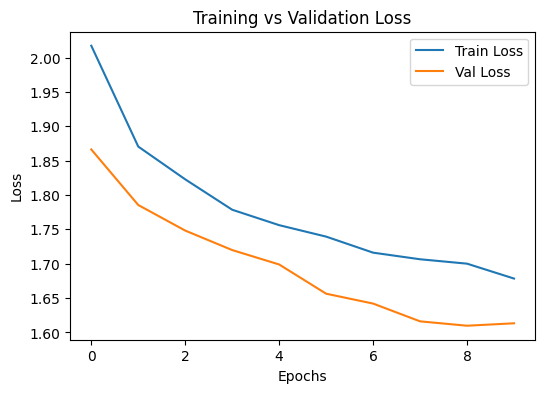

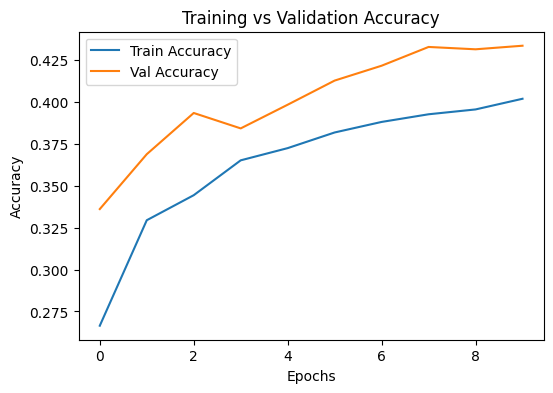

In [4]:
# Problem 1
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, ParameterGrid

#Part (a)

# Load dataset
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Normalize pixel values
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatten labels
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# Split 70%-30% for training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.3, random_state=42
)

# Visualize one image from each class
plt.figure(figsize=(10, 4))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[idx])
    plt.title(class_names[i])
    plt.axis('off')
plt.suptitle("Sample Images from CIFAR-10 Classes")
plt.show()

# Part b

# Prepare data for fully connected NN
X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_val_flat = X_val.reshape((X_val.shape[0], -1))

y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)

# Define function to build model
def build_model(hidden_units=256, dropout_rate=0.3, learning_rate=0.001):
    model = Sequential([
        Flatten(input_shape=(32*32*3,)),
        Dense(hidden_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Grid search over hyperparameters
param_grid = {
    'hidden_units': [128, 256],
    'dropout_rate': [0.3, 0.5],
    'learning_rate': [0.001, 0.0005]
}

grid = ParameterGrid(param_grid)

best_val_acc = 0
best_params = None
best_history = None

for params in grid:
    print(f"Training with params: {params}")
    model = build_model(**params)
    history = model.fit(
        X_train_flat, y_train_cat,
        epochs=10, batch_size=128,
        validation_data=(X_val_flat, y_val_cat),
        verbose=0
    )
    val_acc = max(history.history['val_accuracy'])
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params
        best_history = history

print("\nBest Hyperparameters:", best_params)
print("Best Validation Accuracy:", best_val_acc)

# Part c

plt.figure(figsize=(6,4))
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

#Part d

plt.figure(figsize=(6,4))
plt.plot(best_history.history['accuracy'], label='Train Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()






Dataset shape: (1503, 6)
   Frequency_Hz  Angle_of_attack_deg  Chord_length_m  \
0           800                  0.0          0.3048   
1          1000                  0.0          0.3048   
2          1250                  0.0          0.3048   
3          1600                  0.0          0.3048   
4          2000                  0.0          0.3048   

   Free_stream_velocity_m/s  Suction_side_displacement_thickness_m  \
0                      71.3                               0.002663   
1                      71.3                               0.002663   
2                      71.3                               0.002663   
3                      71.3                               0.002663   
4                      71.3                               0.002663   

   Sound_pressure_level_dB  
0                  126.201  
1                  125.201  
2                  125.951  
3                  127.591  
4                  127.461  

Summary statistics:
       Frequency_Hz  A

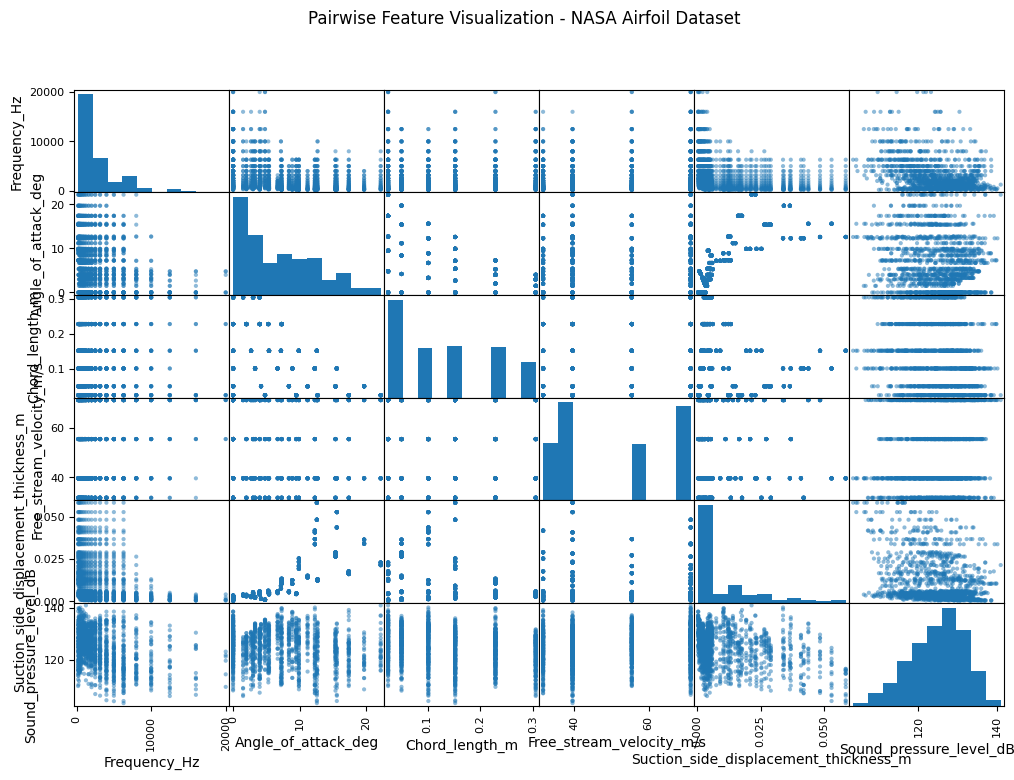

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


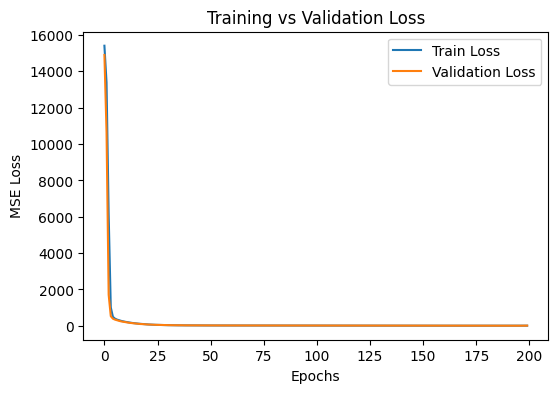

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Coefficient of Determination (R²): 0.7040


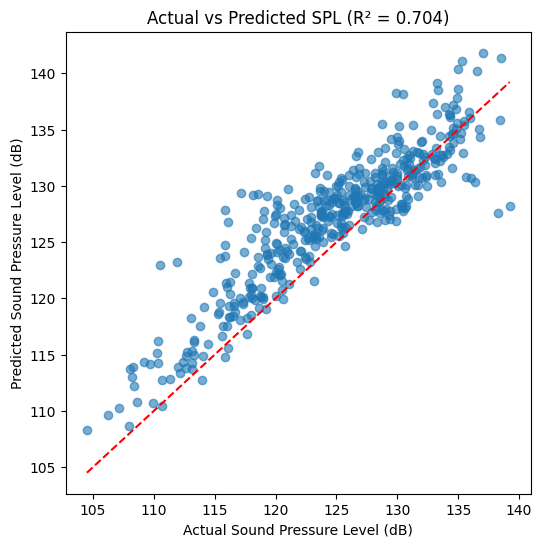

In [5]:
# Problem 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Part a

# Load the dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat"

# The dataset has no header; specify column names
col_names = [
    "Frequency_Hz", "Angle_of_attack_deg", "Chord_length_m",
    "Free_stream_velocity_m/s", "Suction_side_displacement_thickness_m",
    "Sound_pressure_level_dB"
]

df = pd.read_csv(url, sep="\t", names=col_names)

print("Dataset shape:", df.shape)
print(df.head())

# Basic statistics
print("\nSummary statistics:")
print(df.describe())

# Pairwise visualization
pd.plotting.scatter_matrix(df, figsize=(12, 8), diagonal='hist')
plt.suptitle("Pairwise Feature Visualization - NASA Airfoil Dataset")
plt.show()

#Part b

# Split features and target
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 70-30 train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# Define the fully connected neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # output layer for regression
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    verbose=0
)

# Plot training and validation loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Part c

y_pred = model.predict(X_val)
r2 = r2_score(y_val, y_pred)
print(f"Coefficient of Determination (R²): {r2:.4f}")

# Scatter plot: actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_pred, alpha=0.6)
plt.xlabel("Actual Sound Pressure Level (dB)")
plt.ylabel("Predicted Sound Pressure Level (dB)")
plt.title(f"Actual vs Predicted SPL (R² = {r2:.3f})")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.show()






















































































